# EMA6938 - Data Science for Materials
## Week 8 Lab Notebook: Classification Methods

**Name:** *Ryan Tuggle*  
**Date:** *7/1/2026*  
**Kernel:** Python (matds)

---

**Chapters:** Sandfeld Ch. 14  
**Format:** Take-home - due **Sunday 11:59 PM**  
**Dataset:** `data/week8_mp_classification.csv` (instructor-provided)

---

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lecture. Run them, understand them.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers. Replace the italic placeholder text.

This notebook has 7 parts:

| Part | Title | Connects to |
|------|-------|-------------|
| A | Load & Inspect | Lecture Segment 1 |
| B | Split & Scale | Lecture Segment 1 |
| C | Train Five Classifiers | Lecture Segment 2 |
| D | ROC and PR Curves | Lecture Segment 3 |
| E | Class Imbalance Handling | Lecture Segment 5 |
| F | Logistic Regression Coefficients | Lecture Segment 3 |
| G | Reflection | All segments |

---

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** If you used any AI coding assistant (GitHub Copilot, ChatGPT, etc.) while completing this notebook, describe briefly which tool, for what purpose, and what you verified yourself. Delete this line if no AI tools were used.

In [1]:
# Cell 0 - Environment check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, f1_score, precision_score, recall_score
)

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print("✓ All imports successful")

✓ All imports successful


---
## Part A - Load & Inspect

### A1: Load the dataset

In [2]:
# Cell A1
# LECTURE DEMO
df = pd.read_csv('data/week8_mp_classification.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn names (first 10): {df.columns[:10].tolist()}")
print(f"\nColumn names (last 10): {df.columns[-10:].tolist()}")
print(f"\n{df[['formula','band_gap','is_metallic','crystal_system']].head(8)}")

Shape: (35073, 142)

Column names (first 10): ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom', 'density_g_cm3', 'volume_A3', 'crystal_system', 'is_metallic', 'is_insulating', 'composition']

Column names (last 10): ['MagpieData range GSmagmom', 'MagpieData mean GSmagmom', 'MagpieData avg_dev GSmagmom', 'MagpieData mode GSmagmom', 'MagpieData minimum SpaceGroupNumber', 'MagpieData maximum SpaceGroupNumber', 'MagpieData range SpaceGroupNumber', 'MagpieData mean SpaceGroupNumber', 'MagpieData avg_dev SpaceGroupNumber', 'MagpieData mode SpaceGroupNumber']

       formula  band_gap  is_metallic crystal_system
0  Li3Ni(BO3)2  1.233700            0      Triclinic
1      PrNb3O9  2.848500            0     Monoclinic
2   Li2V(PO4)2  1.399900            0       Trigonal
3     LiCoGeO4  1.621000            0     Monoclinic
4      LiTiVO4  1.474800            0      Triclinic
5   Sr3Nb2ZnO9  2.678041            0       Trigonal
6    Be(FeO2)2  1.750700            0   Orthorhombic
7         SiO2  5.5

### A2: Class balance check

> **Always check class balance before splitting or training anything.**

Class distribution:
is_metallic
0    26305
1     8768
Name: count, dtype: int64

Class proportions:
is_metallic
0    0.75
1    0.25
Name: proportion, dtype: float64


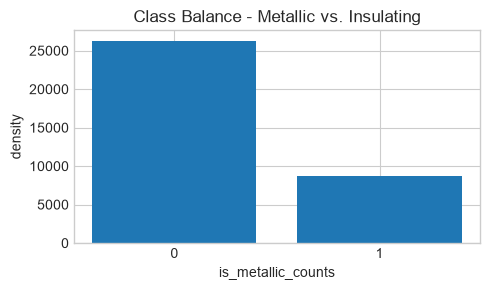


Metallic-to-insulating ratio: 0.33:1


In [3]:
# Cell A2 - Value counts for the target variable
# TASK CELL
print("Class distribution:")
print(df['is_metallic'].value_counts())
print(f"\nClass proportions:")
print(df['is_metallic'].value_counts(normalize=True).round(3))

# Bar chart
fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(df['is_metallic'].value_counts().index.astype(str),df['is_metallic'].value_counts().values)
ax.set_xlabel('is_metallic_counts')
ax.set_ylabel('density')
ax.set_title('Class Balance - Metallic vs. Insulating')
    # YOUR CODE: plot value counts for is_metallic as a bar chart
# Label axes clearly. Title: 'Class Balance - Metallic vs. Insulating'

    
plt.tight_layout()
plt.savefig('A2_class_balance.png', dpi=150)
plt.show()

print(f"\nMetallic-to-insulating ratio: {df['is_metallic'].mean()/(1-df['is_metallic'].mean()):.2f}:1")

### A3: Feature matrix setup

In [4]:
# Cell A3 — Identify MAGPIE feature columns (all float columns except known non-feature columns)
# LECTURE DEMO
non_feature_cols = ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom', 'volume_A3',
                    'density_g_cm3', 'crystal_system', 'is_metallic', 'is_insulating',
                    'composition']  # composition object column from featurization

feature_cols = [c for c in df.columns if c not in non_feature_cols
                and df[c].dtype in ['float64', 'float32']]

print(f"Number of MAGPIE features: {len(feature_cols)}")

# Set up X and y
X = df[feature_cols].values
y = df['is_metallic'].values

# Drop rows with NaN in X or y
mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
X = X[mask]
y = y[mask]

print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")
print(f"Class balance after cleaning: {y.mean():.1%} metallic")

Number of MAGPIE features: 132
Final X shape: (35073, 132)
Final y shape: (35073,)
Class balance after cleaning: 25.0% metallic


---
## Part B - Split & Scale

### B1: Stratified train/test split

> **Rule:** stratify=y ensures class balance is preserved in both splits.

In [5]:
# Cell B1
# LECTURE DEMO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train class balance: {y_train.mean():.1%} metallic")
print(f"Test class balance:  {y_test.mean():.1%} metallic")

Train size: 28,058  |  Test size: 7,015
Train class balance: 25.0% metallic
Test class balance:  25.0% metallic


### B2: StandardScaler - fit on training set ONLY

In [6]:
# Cell B2
# LECTURE DEMO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)          # transform only on test (no fit!)

print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"X_train_scaled std  (should be ~1): {X_train_scaled.std():.4f}")
print(f"X_test_scaled  mean (not guaranteed ~0): {X_test_scaled.mean():.4f}")

X_train_scaled mean (should be ~0): -0.0000
X_train_scaled std  (should be ~1): 0.9692
X_test_scaled  mean (not guaranteed ~0): 0.0022


---
## Part C - Train Five Classifiers

### C1: Logistic Regression

In [7]:
# Cell C1
# LECTURE DEMO
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

  insulating       0.87      0.66      0.75      5261
    metallic       0.40      0.69      0.51      1754

    accuracy                           0.67      7015
   macro avg       0.63      0.68      0.63      7015
weighted avg       0.75      0.67      0.69      7015

ROC-AUC: 0.741


### C2: k-Nearest Neighbours

In [8]:
# Cell C2
# LECTURE DEMO
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("=== k-Nearest Neighbours (k=5) ===")
print(classification_report(y_test, y_pred_knn, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_knn):.3f}")

c:\Users\RXT0TKQ\AppData\Local\miniconda3\miniconda\envs\matds\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


=== k-Nearest Neighbours (k=5) ===
              precision    recall  f1-score   support

  insulating       0.85      0.91      0.88      5261
    metallic       0.65      0.51      0.57      1754

    accuracy                           0.81      7015
   macro avg       0.75      0.71      0.72      7015
weighted avg       0.80      0.81      0.80      7015

ROC-AUC: 0.808


### C3: Gaussian Naive Bayes

In [9]:
# Cell C3
# LECTURE DEMO
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)  # NB does not need scaling

y_pred_nb = nb_clf.predict(X_test)
y_prob_nb = nb_clf.predict_proba(X_test)[:, 1]

print("=== Gaussian Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_nb):.3f}")

=== Gaussian Naive Bayes ===
              precision    recall  f1-score   support

  insulating       0.79      0.85      0.81      5261
    metallic       0.40      0.31      0.35      1754

    accuracy                           0.71      7015
   macro avg       0.59      0.58      0.58      7015
weighted avg       0.69      0.71      0.70      7015

ROC-AUC: 0.655


### C4: Decision Tree

In [10]:
# Cell C4
# LECTURE DEMO
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=SEED)
dt.fit(X_train, y_train) # DT does not need scaling

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("=== Decision Tree (max_depth=5) ===")
print(classification_report(y_test, y_pred_dt, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.3f}")

=== Decision Tree (max_depth=5) ===
              precision    recall  f1-score   support

  insulating       0.86      0.77      0.81      5261
    metallic       0.47      0.61      0.53      1754

    accuracy                           0.73      7015
   macro avg       0.66      0.69      0.67      7015
weighted avg       0.76      0.73      0.74      7015

ROC-AUC: 0.745


### C5: Support Vector Machine

> **Note:** SVC with `kernel="rbf"` is slow on large datasets. If training takes >5 min, use the subsample below.

In [11]:
# Cell C5 - Subsample if dataset is large
# LECTURE DEMO
MAX_SVC = 3000
if len(X_train_scaled) > MAX_SVC:
    idx = np.random.RandomState(SEED).choice(len(X_train_scaled), MAX_SVC, replace=False)
    X_svc = X_train_scaled[idx]
    y_svc = y_train[idx]
    print(f"Using subsample of {MAX_SVC} for SVC training")
else:
    X_svc, y_svc = X_train_scaled, y_train

svm = SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=SEED)
svm.fit(X_svc, y_svc)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

print("=== Support Vector Machine (RBF kernel) ===")
print(classification_report(y_test, y_pred_svm, target_names=['insulating', 'metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.3f}")

Using subsample of 3000 for SVC training


c:\Users\RXT0TKQ\AppData\Local\miniconda3\miniconda\envs\matds\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== Support Vector Machine (RBF kernel) ===
              precision    recall  f1-score   support

  insulating       0.87      0.70      0.77      5261
    metallic       0.43      0.69      0.53      1754

    accuracy                           0.69      7015
   macro avg       0.65      0.69      0.65      7015
weighted avg       0.76      0.69      0.71      7015

ROC-AUC: 0.753


### C6: Task - Comparison Table

Fill in the table below with your results. Then answer the reflection question.

In [12]:
# Cell C6 — Helper function to compute all metrics
# LECTURE DEMO
def get_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model': name,
        'Accuracy':  round((y_true == y_pred).mean(), 3),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall_met':     round(recall_score(y_true, y_pred), 3), #modified line
        'Recall_ins':     round(recall_score(y_true, y_pred, pos_label=0), 3), #modified line
        'F1':        round(f1_score(y_true, y_pred), 3),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 3),
    }

results = [
    get_metrics(y_test, y_pred_lr,  y_prob_lr,  'Logistic Regression'),
    get_metrics(y_test, y_pred_knn, y_prob_knn, 'k-NN (k=5)'),
    get_metrics(y_test, y_pred_nb,  y_prob_nb,  'Naive Bayes'),
    get_metrics(y_test, y_pred_dt,  y_prob_dt,  'Decision Tree'),
    get_metrics(y_test, y_pred_svm, y_prob_svm, 'SVM (RBF)'),
]

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     Accuracy  Precision  Recall_met  Recall_ins     F1  ROC-AUC
Model                                                                           
Logistic Regression     0.667      0.403       0.693       0.658  0.510    0.741
k-NN (k=5)              0.809      0.653       0.505       0.910  0.570    0.808
Naive Bayes             0.711      0.398       0.305       0.846  0.345    0.655
Decision Tree           0.733      0.473       0.611       0.773  0.533    0.745
SVM (RBF)               0.695      0.431       0.685       0.698  0.529    0.753


**Reflection C6 - Fill in this cell:**

Which model achieved the highest ROC-AUC? Which achieved the best recall for the minority (insulating) class?
Describe the decision boundary of your best model geometrically. Is it a hyperplane, a curved surface, or a set of axis-aligned boxes?

*Your answer here*

The model that acheived the highest ROC-AUC was the k-NN model. For insulators the model which had the highest recall was the also the k-NN model. The decision model for the k-NN model is a Voronoi-like boundary which resembles grain boundaries within a crystal. It is not a hyperplane, curved-surface, or a set of axis-aligned boxes. 


---
## Part D - ROC and PR Curves

### D1: ROC curves for all five models

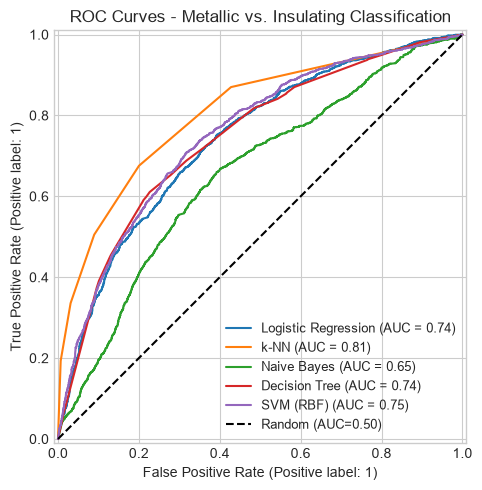

In [13]:
# Cell D1
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(7, 5))

for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('k-NN',                y_pred_knn, y_prob_knn),
    ('Naive Bayes',         y_pred_nb, y_prob_nb),
    ('Decision Tree',       y_pred_dt, y_prob_dt),
    ('SVM (RBF)',           y_pred_svm, y_prob_svm),
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

ax.plot([0,1],[0,1],'k--',label='Random (AUC=0.50)')
ax.set_title('ROC Curves - Metallic vs. Insulating Classification')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('D1_roc_curves.png', dpi=150)
plt.show()

### D2: Precision-Recall curve for the best model

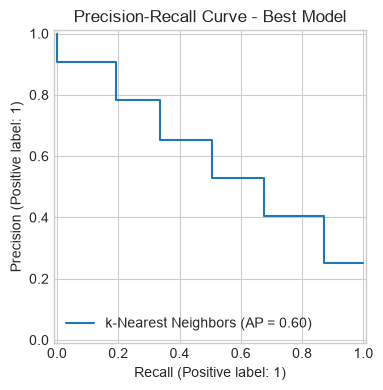

In [14]:
# Cell D2 — YOUR TASK: replace 'y_prob_lr' with the probability output of YOUR best model
# TASK CELL
fig, ax = plt.subplots(figsize=(6, 4))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_knn,   # <-- change to your best model
    name='k-Nearest Neighbors', ax=ax)
ax.set_title('Precision-Recall Curve - Best Model')
plt.tight_layout()
plt.savefig('D2_pr_curve.png', dpi=150)
plt.show()

### D3: Task - Threshold Tuning

> Find the decision threshold at which precision >= 0.85 for the metallic class. Report the recall at that threshold.

In [15]:
# Cell D3
# TASK CELL
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_lr)
type(precision_vals)

# Find thresholds where precision >= 0.85
df_thresh=pd.DataFrame({'precision':precision_vals[:-1],'recall':recall_vals[:-1],'thresholds':thresholds})
df_fil=df_thresh[df_thresh['precision']>=0.85]

for _, row in df_fil.iterrows():
    print(f"Threshold: {row['thresholds']}, Precision: {row['precision']}, Recall: {row['recall']}")

# YOUR CODE HER
# Hint: iterate over (precision_vals, recall_vals, thresholds)
# and find the threshold where precision >= 0.85

# Print: threshold value, precision at that threshold, recall at that threshold

Threshold: 0.9694423459556673, Precision: 0.85, Recall: 0.009692132269099202
Threshold: 0.971980379102046, Precision: 0.875, Recall: 0.00798175598631699
Threshold: 0.9721831415912926, Precision: 0.8666666666666667, Recall: 0.007411630558722919
Threshold: 0.9749463509648789, Precision: 0.8571428571428571, Recall: 0.0068415051311288486
Threshold: 0.981712874795254, Precision: 0.9090909090909091, Recall: 0.005701254275940707
Threshold: 0.9856387215449786, Precision: 0.9, Recall: 0.005131128848346636
Threshold: 0.986247811107034, Precision: 1.0, Recall: 0.005131128848346636
Threshold: 0.9870640618150709, Precision: 1.0, Recall: 0.004561003420752566
Threshold: 0.9962229796186759, Precision: 1.0, Recall: 0.003990877993158495
Threshold: 0.9999441020859067, Precision: 1.0, Recall: 0.0034207525655644243
Threshold: 0.9999700681975933, Precision: 1.0, Recall: 0.0028506271379703536
Threshold: 0.9999947641124757, Precision: 1.0, Recall: 0.002280501710376283
Threshold: 0.999999726075554, Precision: 

---
## Part E - Class Imbalance Handling

### E1: Logistic Regression WITHOUT class_weight (naive baseline)

In [16]:
# Cell E1
# LECTURE DEMO
lr_naive = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
lr_naive.fit(X_train_scaled, y_train)

y_pred_naive = lr_naive.predict(X_test_scaled)
y_prob_naive = lr_naive.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression — NO class_weight ===")
print(classification_report(y_test, y_pred_naive, target_names=['insulating','metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_naive):.3f}")

=== Logistic Regression — NO class_weight ===
              precision    recall  f1-score   support

  insulating       0.79      0.95      0.86      5261
    metallic       0.61      0.23      0.33      1754

    accuracy                           0.77      7015
   macro avg       0.70      0.59      0.60      7015
weighted avg       0.74      0.77      0.73      7015

ROC-AUC: 0.739


### E2: SMOTE - Synthetic Minority Oversampling

> Install if needed: `pip install imbalanced-learn`

In [17]:
# Cell E2
# LECTURE DEMO
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print(f"Original training class balance: {y_train.mean():.1%} metallic")
print(f"SMOTE training class balance:    {y_train_sm.mean():.1%} metallic")
print(f"SMOTE training size: {len(X_train_sm):,}")

lr_smote = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
lr_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = lr_smote.predict(X_test_scaled)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression — SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['insulating','metallic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_smote):.3f}")

Original training class balance: 25.0% metallic
SMOTE training class balance:    50.0% metallic
SMOTE training size: 42,088

=== Logistic Regression — SMOTE ===
              precision    recall  f1-score   support

  insulating       0.86      0.66      0.75      5261
    metallic       0.40      0.69      0.51      1754

    accuracy                           0.67      7015
   macro avg       0.63      0.67      0.63      7015
weighted avg       0.75      0.67      0.69      7015

ROC-AUC: 0.741


### E3: Task - Comparison Table + Reflection

In [18]:
# Cell E3
imbalance_results = [
    get_metrics(y_test, y_pred_naive, y_prob_naive, 'LR - no handling'),
    get_metrics(y_test, y_pred_lr,    y_prob_lr,    'LR - class_weight'),
    get_metrics(y_test, y_pred_smote, y_prob_smote, 'LR - SMOTE'),
]
print(pd.DataFrame(imbalance_results).set_index('Model').to_string())

                   Accuracy  Precision  Recall_met  Recall_ins     F1  ROC-AUC
Model                                                                         
LR - no handling      0.770      0.610       0.227       0.952  0.331    0.739
LR - class_weight     0.667      0.403       0.693       0.658  0.510    0.741
LR - SMOTE            0.669      0.404       0.685       0.663  0.508    0.741


**Reflection E3 - Fill in this cell:**

Compare the three rows in the table. What effect did `class_weight="balanced"` have on precision vs. recall compared to the naive baseline?
What effect did SMOTE have?

For a high-throughput materials screening pipeline, where you are filtering 100,000 candidate compounds and will experimentally test everything that passes the filter, which approach would you use, and why?

*Your answer here*

The class_weight balanced option decreased the precision and increased the recall compared to the naive baseline. SMOTE similarly increased the recall at the expense of the precision and did so virtually to the same extent as the class_weight balanced option. For a high throughput materials screening process I would select the naive baseline option because it returns the highest precsion. In the case of having a massive number of materials to screen experiemntally, I would only want to spend time testing materials that have a high likelihood of actually being in the catregory I am interested in. A higher precision lessens the likelihood I am dealing with a false positive. 

---
## Part F - Logistic Regression Coefficients

### F1: Top features for metallic vs. insulating prediction

In [19]:
# Cell F1
coef_series = pd.Series(lr.coef_[0], index=feature_cols)

print("Top 10 features predicting METALLIC (positive coefficients):")
print(coef_series.nlargest(10).round(4).to_string())

print("\nTop 10 features predicting INSULATING (negative coefficients):")
print(coef_series.nsmallest(10).round(4).to_string())

Top 10 features predicting METALLIC (positive coefficients):
MagpieData mean Electronegativity       2.2795
MagpieData mean CovalentRadius          1.7424
MagpieData avg_dev NdValence            1.2932
MagpieData mean AtomicWeight            1.2013
MagpieData mean MeltingT                1.1977
MagpieData mode AtomicWeight            1.1227
MagpieData avg_dev Electronegativity    0.6641
MagpieData avg_dev GSvolume_pa          0.6414
MagpieData mean NfUnfilled              0.6020
MagpieData mode NpUnfilled              0.5754

Top 10 features predicting INSULATING (negative coefficients):
MagpieData avg_dev CovalentRadius   -1.5351
MagpieData mode Number              -1.4406
MagpieData avg_dev MeltingT         -1.1714
MagpieData mean NdValence           -1.1226
MagpieData mean GSbandgap           -1.0188
MagpieData mean NpUnfilled          -0.9968
MagpieData mean GSvolume_pa         -0.9456
MagpieData mean Number              -0.8071
MagpieData avg_dev NfUnfilled       -0.7483
MagpieDat

### F2: Coefficient bar chart

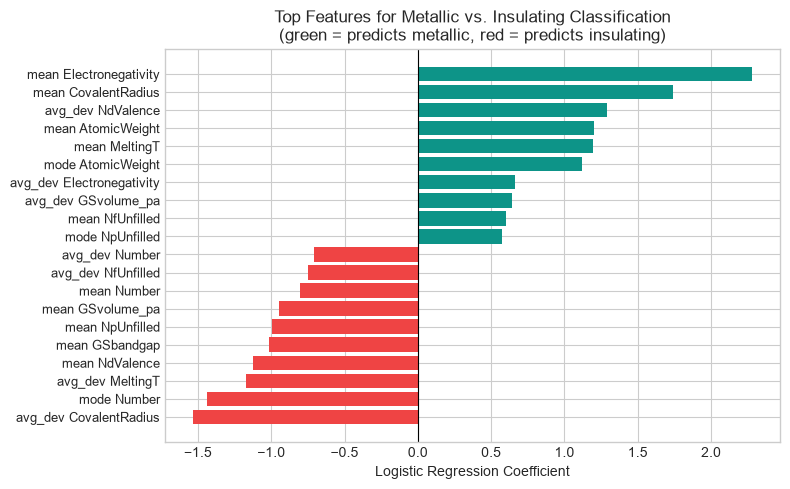

In [20]:
# Cell F2
top10_pos = coef_series.nlargest(10)
top10_neg = coef_series.nsmallest(10)
top20 = pd.concat([top10_neg, top10_pos]).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#0D9488' if v > 0 else '#EF4444' for v in top20.values]
ax.barh(range(len(top20)), top20.values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f.replace('MagpieData ','') for f in top20.index], fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Top Features for Metallic vs. Insulating Classification\n(green = predicts metallic, red = predicts insulating)')
plt.tight_layout()
plt.savefig('F2_lr_coefficients.png', dpi=150)
plt.show()

### F3: Task - Physical interpretation

Interpret the top positive and top negative coefficients physically.

- **Top positive feature (predicts metallic):** Why would high values of this composition descriptor suggest metallic character? Connect to band structure or bonding.
- **Top negative feature (predicts insulating):** Why would high values predict insulating character?
- **Compare to Week 5/6:** Do the same MAGPIE features that predicted high bandgap (Week 5) also predict insulating character here?

*Your answer here*

The top positive feature of mean electronegativity suggests metallic character in this case because the compounds in the dataset primarily consist of metallic materials with elements with moderate electronegativities that are similar to one another in electronegatvity which creates more orbital overlap and that gives a small to zero bandgap. This effect could also be showing up more with this dataset because the insulators do not have a high mean electronegativity. 

The top negative feature is avg_dev covalent radius. High values predict insulating character because a large difference in radius suggets a cation and anion of substantially different size which occurs often with ionic bonding and causes a substantial bandgap to form because of valence states being more localized.  

In Week 5, the feature importance plot revealed  that the avg_dev in d valence orbitals and melting point most predicted the bandgap. Melting point predits insulating character here and mean nd_valence predicts insulating character. In week 5, mean Ndvalence was also near the top of the feature importance chart for bandgap wo there is a close match here. 



---
## Part G - Reflection

### G1: Connection to Week 5 RF Feature Importance

In 3-4 sentences, connect the logistic regression coefficients from Part F to the random forest feature importance from Week 5 (bandgap prediction).

- Do the same features appear near the top?
- If a feature predicted HIGH bandgap in Week 5 (positive RF importance), does it also predict INSULATING here (negative LR coefficient)?
- What does this pattern tell you about the relationship between the two models?

*Your answer here*

The only feature that appears near the top of each is avg dev Ndvalence. The features that predicted high bandgap in week 5, mean Ndvalence, melting T, Number, and GSbandgap also appear as negative coefficients here and predict insulating. This pattern tells me that both models are encoding the same physical mechanisms to predict bandgap and insulating character. 

### G2: Classification problem in your own research

Think of a binary (or multi-class) classification problem relevant to your own research. In 3–4 sentences:

1. What are the target **classes**? (e.g. stable/unstable, conductor/insulator, crystalline/amorphous)
2. What **features** would you use?
3. Which **metric** would you optimise? Accuracy, precision, recall, F1, or AUC and why?

*Your answer here*

For my research in lithium ion battery cells the classes would be normal vs. accelerated ageing. The features I would use for this would be temperature, time, cycles, SOC, etc. The property to have as y-train could be SOH at 1 year or something similar. I would optimize for precision because the accelerated ageing is not a rare property and I would want to bias against having false positive results. 

---
## Day 2 Demo

### Demo 1 - Threshold sensitivity: precision–recall trade-off

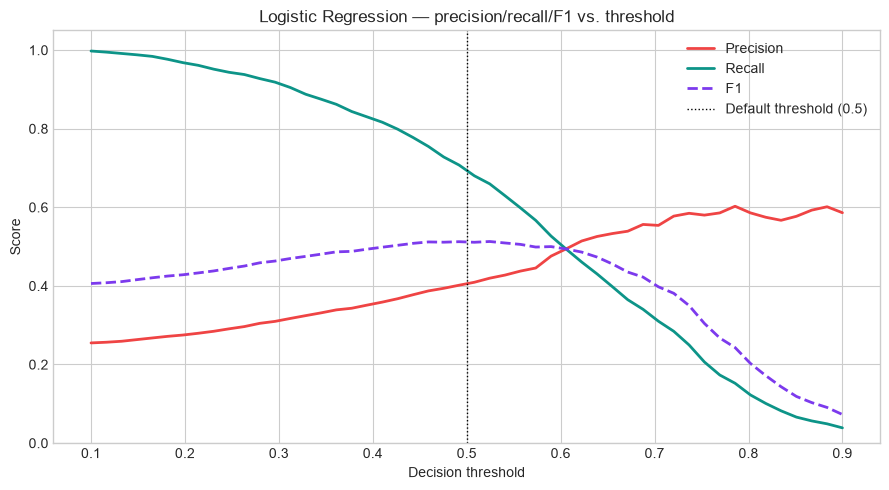

Best F1 = 0.513 at threshold = 0.52
  Precision at best F1: 0.420
  Recall    at best F1: 0.660


In [21]:
# Cell Demo 1 — Threshold sensitivity for the best classifier
# LECTURE DEMO

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Use the best model from Part C (assumed to be rf or lr — adjust as needed)
# Get probability scores for the positive class (metallic=1)
try:
    probs = rf.predict_proba(X_test_scaled)[:, 1]
    model_name = 'Random Forest'
except:
    probs = lr.predict_proba(X_test_scaled)[:, 1]
    model_name = 'Logistic Regression'

thresholds = np.linspace(0.1, 0.9, 50)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    y_pred_t = (probs >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, color='#EF4444', lw=2, label='Precision')
ax.plot(thresholds, recalls,   color='#0D9488', lw=2, label='Recall')
ax.plot(thresholds, f1s,       color='#7C3AED', lw=2, label='F1', ls='--')
ax.axvline(0.5, color='black', lw=1, ls=':', label='Default threshold (0.5)')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
ax.set_title(f'{model_name} — precision/recall/F1 vs. threshold')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
#plt.savefig('Day2_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

best_f1_idx = np.argmax(f1s)
print(f"Best F1 = {f1s[best_f1_idx]:.3f} at threshold = {thresholds[best_f1_idx]:.2f}")
print(f"  Precision at best F1: {precisions[best_f1_idx]:.3f}")
print(f"  Recall    at best F1: {recalls[best_f1_idx]:.3f}")

### Demo 2 - DT coefficients

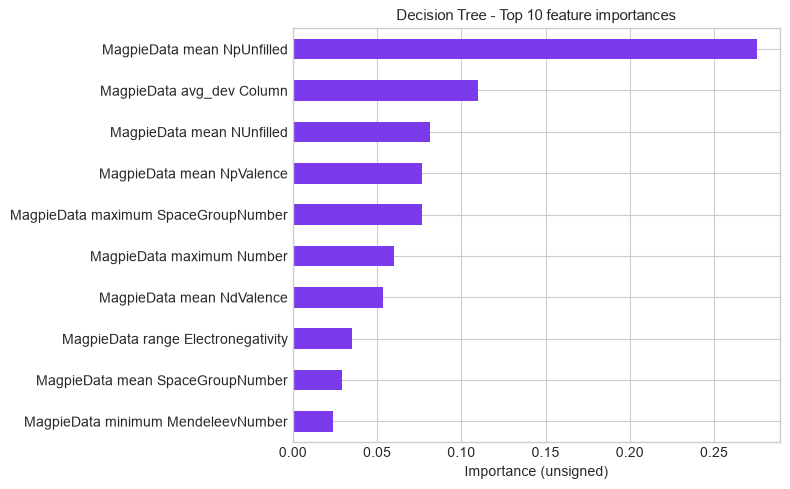

Top 5 LR coefficients (signed, by magnitude):
MagpieData mean Electronegativity    2.279535
MagpieData mean CovalentRadius       1.742437
MagpieData avg_dev CovalentRadius   -1.535065
MagpieData mode Number              -1.440580
MagpieData avg_dev NdValence         1.293190
dtype: float64

Top 5 Decision Tree importances (unsigned):
MagpieData mean NpUnfilled             0.275384
MagpieData avg_dev Column              0.109913
MagpieData mean NUnfilled              0.081634
MagpieData mean NpValence              0.076732
MagpieData maximum SpaceGroupNumber    0.076638
dtype: float64


In [22]:
# Cell Demo 2 — Decision Tree feature importances for comparison
# LECTURE DEMO

dt_importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
dt_importances.head(10).sort_values().plot(kind='barh', color='#7C3AED', ax=ax)
ax.set_title('Decision Tree - Top 10 feature importances', fontsize=11)
ax.set_xlabel('Importance (unsigned)')
plt.tight_layout()
plt.show()

print("Top 5 LR coefficients (signed, by magnitude):")
print(coef_series.reindex(coef_series.abs().sort_values(ascending=False).index).head(5))
print("\nTop 5 Decision Tree importances (unsigned):")
print(dt_importances.head(5))

**Day 2 Discussion questions:**

1. From Demo 1: if you were building a high-throughput screening pipeline to find insulating oxides, would you raise or lower the threshold from 0.5? What do you sacrifice in exchange?

2. From Demo 2: compare the LR coefficients from cell F2 to the Decision Tree's .feature_importances_. Do the same features appear at the top? If they disagree, what does that tell you about the different ways a linear model (signed coefficients, one global boundary) and a tree-based model (unsigned importances, sequential axis-aligned splits) identify which features matter for the metallic/insulating boundary?

1. If I were building a high throughput screening pipeline to find insulating oxides and I don't need to experiemntally validate them I would lower the threshold from 0.5 to ensure that I don't miss many true positive results. This will sacrifice the precsision and I will inevitably end up with more false psotive results also.

2. In comparing the top features from LR and the decision tree model it is evident that the top features are not the same. The fact that they disagree indicates that a linear model with signed coefficients is determining top feature coefficients by determining those features that influence all the datapoints increase monotonically towards a specific class while the decison tree is looking for any features that that reduce impurity even if its a local effect across a subset of the dataset and the direction is not necessarily monotonic. 

---
## Submission Checklist

Before submitting, confirm all cells have been executed:

- [ ] A2: Class balance bar chart saved
- [ ] C6: Comparison table printed and reflection filled in
- [ ] D1: ROC curves for all five models saved
- [ ] D2: PR curve for best model saved
- [ ] D3: Threshold tuning answer filled in
- [ ] E3: Imbalance comparison table and reflection filled in
- [ ] F2: Coefficient bar chart saved
- [ ] F3, G1, G2, Day2: All reflection cells answered
- [ ] All reflection cells answered (no placeholder text)
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week8.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.